### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [3]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

# import CTPLIB as ctp


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [5]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('../data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [7]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [9]:
# Check for Nulls.
df.isnull().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [11]:
# Check for Duplicates
df.duplicated().unique()

array([False])

#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [14]:
def inspect_dataframe(input_df):
    # DISPLAY THE FIRST 5 ROWS
    print(input_df.head())

    print(df.describe())

    print("\nany null values:")
    print(input_df.isnull().sum())
    
    print("\nany duplicate values:")
    print(input_df.duplicated().unique())
    
    return "That gooood stuff."

inspect_dataframe(df)

   SeasonEnd                 Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
0       1980        Atlanta Hawks         1  50  8573    8334  3261  7027   
1       1980       Boston Celtics         1  61  9303    8664  3617  7387   
2       1980        Chicago Bulls         0  30  8813    9035  3362  6943   
3       1980  Cleveland Cavaliers         0  37  9360    9332  3811  8041   
4       1980       Denver Nuggets         0  30  8878    9240  3462  7470   

     2P   2PA   3P  3PA    FT   FTA   ORB   DRB   AST  STL  BLK   TOV  
0  3248  6952   13   75  2038  2645  1369  2406  1913  782  539  1495  
1  3455  6965  162  422  1907  2449  1227  2457  2198  809  308  1539  
2  3292  6668   70  275  2019  2592  1115  2465  2152  704  392  1684  
3  3775  7854   36  187  1702  2205  1307  2381  2108  764  342  1370  
4  3379  7215   83  255  1871  2539  1311  2524  2079  746  404  1533  
         SeasonEnd    Playoffs           W           PTS        oppPTS  \
count   835.000000  835.000000 

'That gooood stuff.'

#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

Text(0.5, 1.0, 'NBA Team Seasons Distributions')

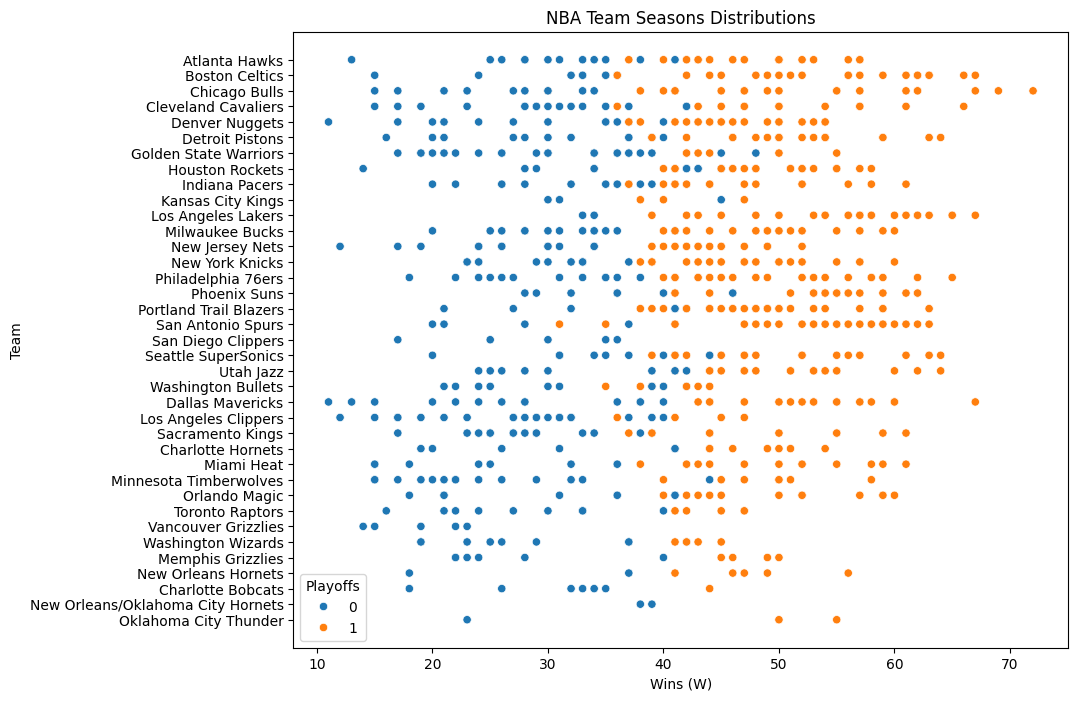

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='W', y='Team', hue='Playoffs')
plt.xlabel('Wins (W)')
plt.title('NBA Team Seasons Distributions')

#### Take a rough estimate, and now use that moving forward.  



In [ ]:
WINS_NEED_TO_MAKE_PLAYOFFS = 42

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


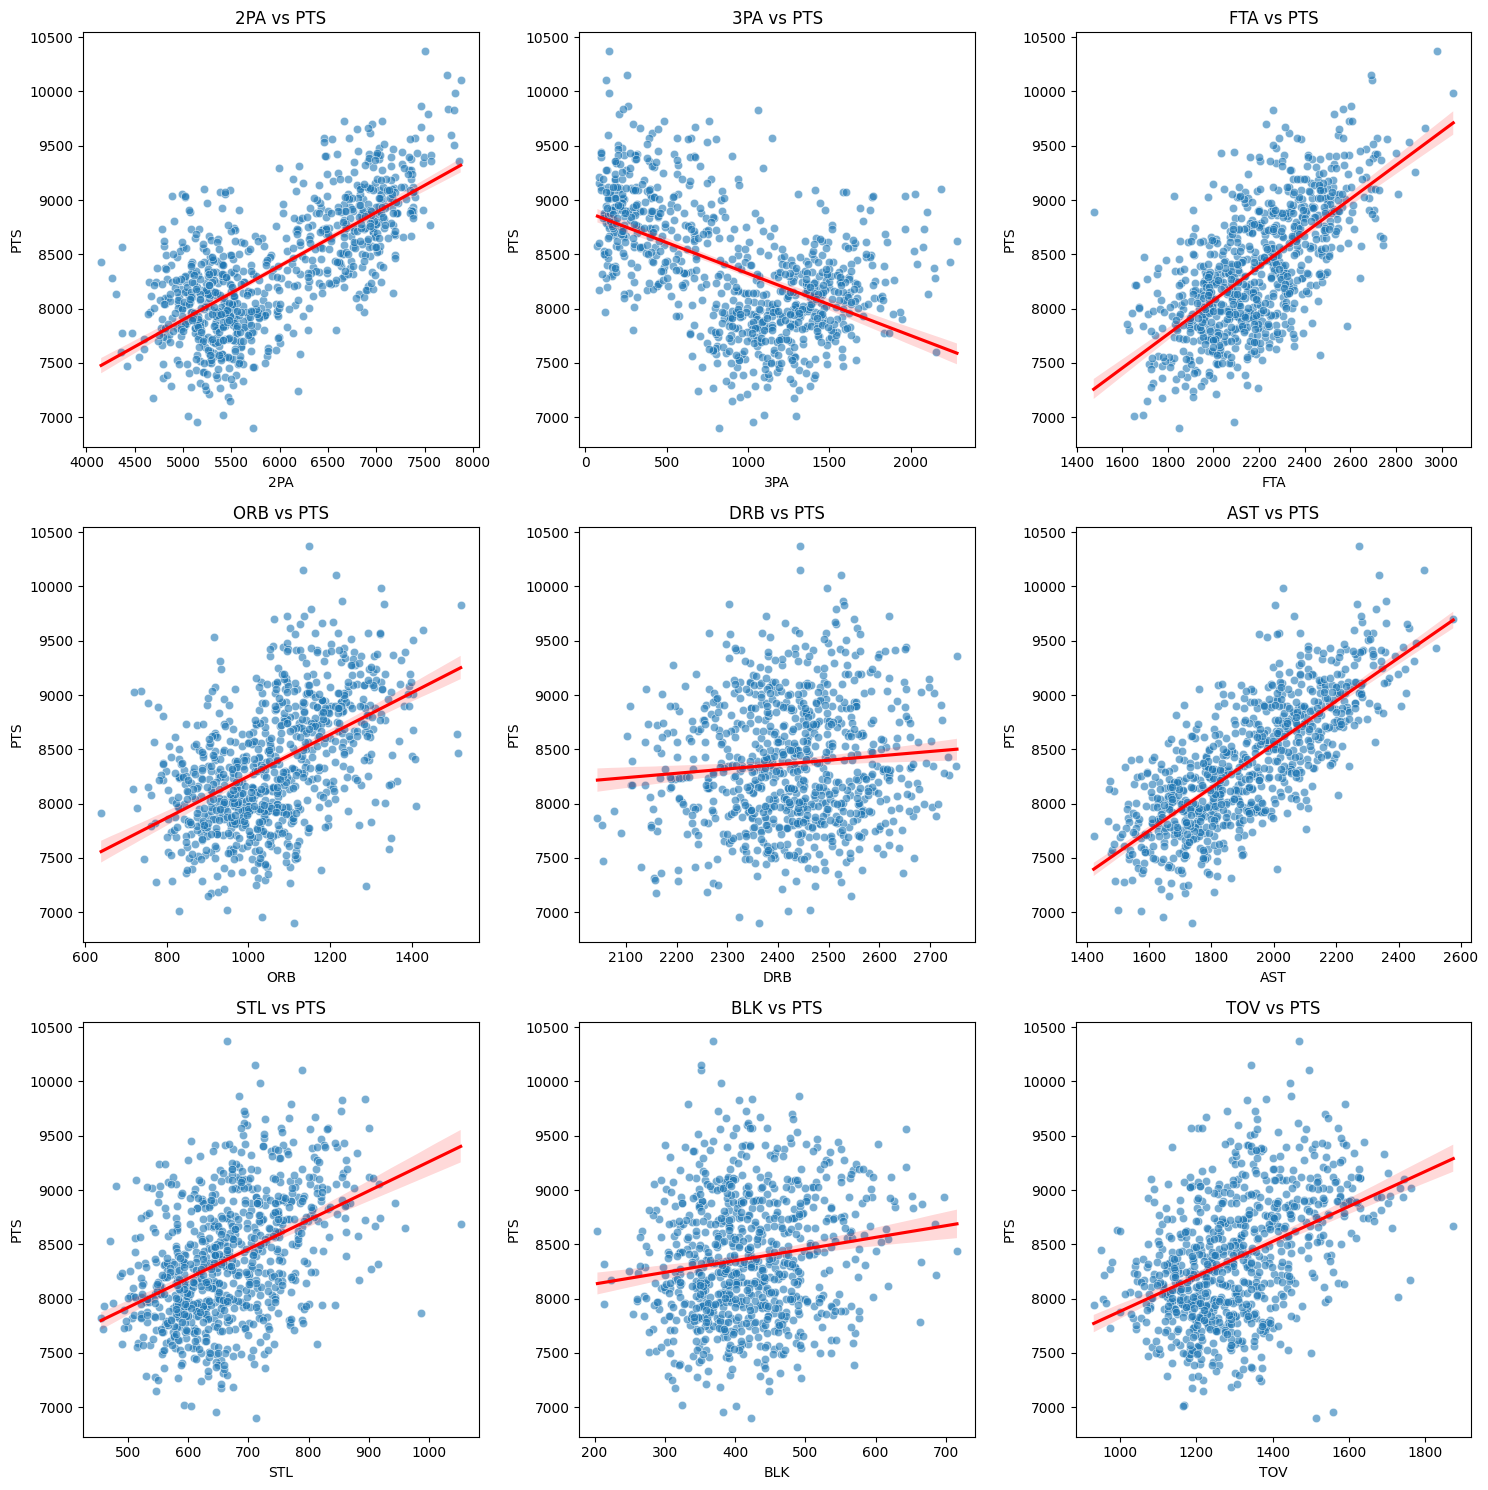

In [23]:
# Example variables
dependent_variable = 'PTS'
independent_variables = ['2PA', '3PA', 'FTA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']

# Set up figure and axes grid
n = len(independent_variables)
cols = 3  # you can change to 2 if you want fewer per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, var in enumerate(independent_variables):
    
    # Create a jointplot, but draw it on a custom axis
    sns.scatterplot(x=df[var], y=df[dependent_variable], ax=axes[i], alpha=0.6)

    # regression plot (aka the red line)
    sns.regplot(x=df[var], y=df[dependent_variable], ax=axes[i], scatter=False, color='red')

    #putting the plot in the subplot
    axes[i].set_title(f'{var} vs {dependent_variable}')

# Hide empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [25]:
dependent_variable = 'PTS'
independent_variables = ['2PA', '3PA', 'FTA', 'AST']

X = df[independent_variables]
y = df[dependent_variable]


## we have to add a constant to our X data (a column of just all 1's)
X = sm.add_constant(X)

# build our model
model_wins = sm.OLS(y, X).fit()

# make new predictions
y_pred = model_wins.predict(X) 

# get the summary report
results = model_wins.summary2()
print(results)


# get root mean squared error
model_wins_root_mean_squared_error = rmse(y, y_pred)
print('#'*79)
print( 'Dependent Variable %s average: ' % dependent_variable, y.mean())
print( 'RMSE:', model_wins_root_mean_squared_error)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.874     
Dependent Variable: PTS              AIC:                11275.4930
Date:               2025-10-30 03:44 BIC:                11299.1301
No. Observations:   835              Log-Likelihood:     -5632.7   
Df Model:           4                F-statistic:        1445.     
Df Residuals:       830              Prob (F-statistic): 0.00      
R-squared:          0.874            Scale:              42605.    
--------------------------------------------------------------------
         Coef.     Std.Err.     t     P>|t|     [0.025      0.975]  
--------------------------------------------------------------------
const  -1646.4006  178.7843  -9.2089  0.0000  -1997.3230  -1295.4781
2PA        0.8013    0.0247  32.4400  0.0000      0.7528      0.8498
3PA        1.1179    0.0364  30.7517  0.0000      1.0465      1.1892
FTA        1.0140    0.0351  28.8564  0.0000      0.9450    

In [26]:
df[independent_variables].corr().round(4)

,2PA,3PA,FTA,AST
2PA,1.0000,-0.9232,0.5238,0.6777
3PA,-0.9232,1.0000,-0.5378,-0.5928
FTA,0.5238,-0.5378,1.0000,0.4280
AST,0.6777,-0.5928,0.4280,1.0000


In [27]:
def eval_regression(input_df, independent_variables, dependent_variable):
    data = input_df.copy()

    # Define the independent and dependent variables
    X = data[independent_variables]  # Independent variable
    y = data[dependent_variable]  # Dependent variable


    # Add a constant to the independent variables (required by statsmodels)
    X = sm.add_constant(X)

    # Split the data into training and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the linear regression model
    model = sm.OLS(y_train, X_train).fit()

    y_pred = model.predict(X_test)
    
    # Rounding the massive long float
    y_pred = round(y_pred,4)

    # Calculate R^2
    r_squared = metrics.r2_score(y_test, y_pred)

    # Rounding the massive long float
    r_squared = round(r_squared, 4)

    # Calculate RMSE
    model_root_mean_squared_error = rmse(y_test, y_pred)

    # Rounding the massive long float
    model_root_mean_squared_error = round(model_root_mean_squared_error, 4)

    print('R-Squared Score:', r_squared)
    print('RMSE:', model_root_mean_squared_error)
    print( 'Dependent Variable %s average: ' % dependent_variable, round(y.mean(), 4))
    precentage_off = round(model_root_mean_squared_error / y.mean() , 4)
    print(f'On average our prediction is %{precentage_off} the dependent variable')
    
    return None

In [31]:
def do_moneyball(input_df, independent_variables, dependent_variable, print_model_summary=True):

    # Copy the data
    data = input_df.copy()

    # Define the independent and dependent variables
    X = data[independent_variables]  # Independent variable
    y = data[dependent_variable]  # Dependent variable

    # Add a constant to the independent variables (required by statsmodels)
    X = sm.add_constant(X)

    # Build the linear regression model
    model = sm.OLS(y, X).fit()
    
    # Make predictions
    y_pred = model.predict(X) 


    # Calculate R^2
    r_squared = metrics.r2_score(y, y_pred)
    r_squared = round(r_squared, 4)


    # Calculate RMSE
    model_root_mean_squared_error = rmse(y, y_pred)
    model_root_mean_squared_error = round(model_root_mean_squared_error, 4)

    # Print model description
    #print('\n'*2)
    print("#"*79)
    print("Predicting:", dependent_variable)
    print("Using:",  independent_variables)
    print("#"*79)
    #print('\n'*2)

    # Print eval metrics
    print('/'*79)
    print('EVAL ON TESTING DATA')
    print('R-Squared Score:', r_squared)
    print('RMSE:', model_root_mean_squared_error)
    print('Dependent Variable %s average: ' % dependent_variable, round(y.mean(), 3))
    print('/'*79)
    #print('\n'*2)

    print('-'*79)
    print('EVAL ON TESTING DATA')
    print(eval_regression(input_df, independent_variables, dependent_variable))
    print('-'*79)
    #print('\n'*2)
    # Return model

    # Print the summary of the model if you want it 
    if print_model_summary:   
        print(model.summary())

    return(model)

selected_features = ['2PA', '3PA', 'FTA', 'AST']
target_feature = 'PTS'

model = do_moneyball(df, independent_variables=selected_features, dependent_variable=target_feature)

###############################################################################
Predicting: PTS
Using: ['2PA', '3PA', 'FTA', 'AST']
###############################################################################
///////////////////////////////////////////////////////////////////////////////
EVAL ON TESTING DATA
R-Squared Score: 0.8744
RMSE: 205.7919
Dependent Variable PTS average:  8370.24
///////////////////////////////////////////////////////////////////////////////
-------------------------------------------------------------------------------
EVAL ON TESTING DATA
R-Squared Score: 0.8851
RMSE: 203.0018
Dependent Variable PTS average:  8370.2395
On average our prediction is %0.0243 the dependent variable
None
-------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                    PTS   R-squared:                       0.874
Model:                            OLS   A

In [50]:
X_vars = ['2PA','FTA']
y_var = 'PTS'
do_moneyball(df, X_vars, y_var)

# not sure how to mitigate multicolinearity

###############################################################################
Predicting: PTS
Using: ['2PA', 'FTA']
###############################################################################
///////////////////////////////////////////////////////////////////////////////
EVAL ON TESTING DATA
R-Squared Score: 0.613
RMSE: 361.2631
Dependent Variable PTS average:  8370.24
///////////////////////////////////////////////////////////////////////////////
-------------------------------------------------------------------------------
EVAL ON TESTING DATA
R-Squared Score: 0.6318
RMSE: 363.365
Dependent Variable PTS average:  8370.2395
On average our prediction is %0.0434 the dependent variable
None
-------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                    PTS   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:  

In [ ]:
# confused by this point

# what_we_are_trying_to_predict = 'PTS'
# data_we_have_related_to_games = ['runs_diff']
# model = do_moneyball(df, data_we_have_related_to_games, what_we_are_trying_to_predict)

# coef_y_int = model.params['const']
# coef_runs_diff = model.params['runs_diff']

# ## y = m*x + b
# ## x = y-b / m

# ### THIS IS SAME AS ABOVE
# y_intercept = 80.88
# m_coefficient = 0.1058
# # x = ???

# y = 95
# x_target = (y - y_intercept) / m_coefficient
# x_target

# independent_variables = ['OBP', 'SLG']
# dependent_variable = 'RS'

# X = df[independent_variables]
# y = df[dependent_variable]

# X = sm.add_constant(X)

# model_runs_scored = sm.OLS(y, X).fit()
# #predictions = mode_runs_scored.predict(X) 
# print(model_runs_scored.summary())